# Gaussian Factor Graphs: LS vs Sum-Product (Gaussian BP)

This notebook demonstrates:

1. A small **Gaussian factor graph** (both tree and loopy versions).
2. **Batch least-squares (LS)** solving of the normal equations (your style).
3. **Gaussian Belief Propagation (GaBP)**, i.e., Sum–Product on a Gaussian factor graph.
4. How GaBP iteratively converges to the same solution as LS.
5. Visualizations of **convergence** and **message flows** (with an interactive slider).

You can execute the cells step-by-step and play with the parameters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List

try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not available; interactive message visualization will be disabled.')

%matplotlib inline


## Define a Simple Gaussian Factor Graph

We use three scalar variables $x_1, x_2, x_3$ with:

- Unary priors (one per variable)
- Pairwise smoothness factors

We will create two graph topologies:

1. **Chain (tree)**: 1 -- 2 -- 3
2. **Loop**: 1 -- 2 -- 3 -- 1


In [2]:
@dataclass
class GaussianFG:
    # number of scalar variables
    n_vars: int = 3
    # unary prior means and std devs
    prior_means: np.ndarray = None
    prior_sigmas: np.ndarray = None
    # pairwise edges as (i, j) indices
    pair_edges: List[Tuple[int, int]] = None
    pair_sigma: float = 0.3

    def __post_init__(self):
        if self.prior_means is None:
            self.prior_means = np.array([1.0, 2.0, 0.0])
        if self.prior_sigmas is None:
            self.prior_sigmas = np.array([0.1, 0.1, 0.1])
        if self.pair_edges is None:
            self.pair_edges = [(0, 1), (1, 2)]  # chain by default

    def build_normal_equations(self):
        """Build A and b so that we solve (A^T A)x = A^T b"""
        rows = []
        rhs = []
        # unary factors
        for i in range(self.n_vars):
            row = np.zeros(self.n_vars)
            row[i] = 1.0 / self.prior_sigmas[i]
            rows.append(row)
            rhs.append(self.prior_means[i] / self.prior_sigmas[i])
        # pairwise smoothness
        for (i, j) in self.pair_edges:
            row = np.zeros(self.n_vars)
            row[i] = 1.0 / self.pair_sigma
            row[j] = -1.0 / self.pair_sigma
            rows.append(row)
            rhs.append(0.0)
        A = np.vstack(rows)
        b = np.array(rhs)
        return A, b


## Batch Least-Squares Solution (MAP)

This is your usual way of solving a Gaussian factor graph: build normal equations and solve them.


In [3]:
# Create two graphs: chain and loop
fg_chain = GaussianFG(pair_edges=[(0, 1), (1, 2)])
fg_loop = GaussianFG(pair_edges=[(0, 1), (1, 2), (2, 0)])

def solve_ls(fg: GaussianFG):
    A, b = fg.build_normal_equations()
    ATA = A.T @ A
    ATb = A.T @ b
    x = np.linalg.solve(ATA, ATb)
    return x

x_chain_ls = solve_ls(fg_chain)
x_loop_ls = solve_ls(fg_loop)
print('LS solution (chain):', x_chain_ls)
print('LS solution (loop): ', x_loop_ls)


LS solution (chain): [1.075 1.75  0.175]
LS solution (loop):  [1.   1.75 0.25]


## Gaussian Belief Propagation (GaBP)

We now implement Sum–Product (in information form) on the same Gaussian factor graphs.

Messages are Gaussians represented by **precision** $\lambda$ and **information** $\eta = \lambda \mu$.

The implementation below is deliberately explicit and logs:
- variable beliefs per iteration
- factor→variable messages per iteration
for later visualization of message flows.


In [4]:
def gaussian_combine(info_pairs: List[Tuple[float, float]]) -> Tuple[float, float]:
    """Combine multiple (prec, info) pairs into one Gaussian."""
    prec = sum(p for p, _ in info_pairs)
    if prec == 0:
        return 0.0, 0.0
    info = sum(i for _, i in info_pairs)
    return prec, info

def run_gabp(fg: GaussianFG, iters: int = 20):
    n = fg.n_vars
    # Factor identifiers:
    # Unary factors: ('u', i)
    # Pairwise factors: ('p', i, j)

    # Initialize messages: dict[(factor_key, var_index)] = (prec, info)
    m_fv: Dict[Tuple, Tuple[float, float]] = {}
    m_vf: Dict[Tuple, Tuple[float, float]] = {}

    # Setup factor keys
    unary_factors = [('u', i) for i in range(n)]
    pair_factors = [('p', i, j) for (i, j) in fg.pair_edges]

    # init all messages to (0,0)
    for i in range(n):
        for fk in unary_factors:
            if fk[1] == i:
                m_fv[(fk, i)] = (0.0, 0.0)
                m_vf[(i, fk)] = (0.0, 0.0)
        for fk in pair_factors:
            _, a, b = fk
            if a == i or b == i:
                m_fv[(fk, i)] = (0.0, 0.0)
                m_vf[(i, fk)] = (0.0, 0.0)

    # Logs
    beliefs = np.zeros((iters, n))  # mean per var per iter
    msg_history = []  # list of dicts m_fv per iter

    # Precompute precisions
    prior_precs = 1.0 / (fg.prior_sigmas ** 2)
    smooth_prec = 1.0 / (fg.pair_sigma ** 2)

    for it in range(iters):
        # 1) factor -> variable messages
        # unary factors: fixed priors
        for i in range(n):
            fk = ('u', i)
            prec = prior_precs[i]
            info = prec * fg.prior_means[i]
            m_fv[(fk, i)] = (prec, info)

        # pairwise factors
        for (i, j) in fg.pair_edges:
            fk = ('p', i, j)
            # Factor enforces x_i ~ x_j (smoothness)

            # message f->i uses incoming from j
            prec_j, info_j = m_vf[(j, fk)]
            if prec_j > 0:
                mu_j = info_j / prec_j
            else:
                mu_j = 0.0
            # we use a simple form: push i towards mu_j with smooth_prec
            m_fv[(fk, i)] = (smooth_prec, smooth_prec * mu_j)

            # message f->j uses incoming from i
            prec_i, info_i = m_vf[(i, fk)]
            if prec_i > 0:
                mu_i = info_i / prec_i
            else:
                mu_i = 0.0
            m_fv[(fk, j)] = (smooth_prec, smooth_prec * mu_i)

        # 2) variable -> factor messages + compute beliefs
        for i in range(n):
            incoming = []
            # from unary
            fk_u = ('u', i)
            incoming.append(m_fv[(fk_u, i)])
            # from pairwise
            for (a, b) in fg.pair_edges:
                fk_p = ('p', a, b)
                if a == i or b == i:
                    incoming.append(m_fv[(fk_p, i)])

            prec_tot, info_tot = gaussian_combine(incoming)
            if prec_tot > 0:
                mu_i = info_tot / prec_tot
            else:
                mu_i = 0.0
            beliefs[it, i] = mu_i

            # send var->factor messages: here we simply send the current belief
            m_vf[(i, fk_u)] = (prec_tot, info_tot)
            for (a, b) in fg.pair_edges:
                fk_p = ('p', a, b)
                if a == i or b == i:
                    m_vf[(i, fk_p)] = (prec_tot, info_tot)

        # log factor->var messages (deep copy for this iteration)
        msg_history.append(dict(m_fv))

    return beliefs, msg_history


## Run GaBP for Chain and Loopy Graphs

We now run Gaussian BP for several iterations in both topologies.


In [5]:
iters = 40
beliefs_chain, msgs_chain = run_gabp(fg_chain, iters=iters)
beliefs_loop, msgs_loop = run_gabp(fg_loop, iters=iters)

print('Final GaBP beliefs (chain):', beliefs_chain[-1])
print('LS solution (chain):        ', x_chain_ls)
print('\nFinal GaBP beliefs (loop): ', beliefs_loop[-1])
print('LS solution (loop):         ', x_loop_ls)


Final GaBP beliefs (chain): [1.075 1.75  0.175]
LS solution (chain):         [1.075 1.75  0.175]

Final GaBP beliefs (loop):  [1.   1.75 0.25]
LS solution (loop):          [1.   1.75 0.25]


## Convergence Plots

We compare GaBP (iterative) vs LS (closed-form) for both chain and loop graphs.


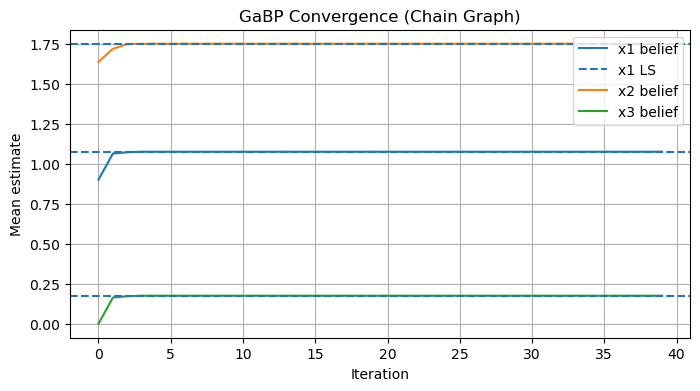

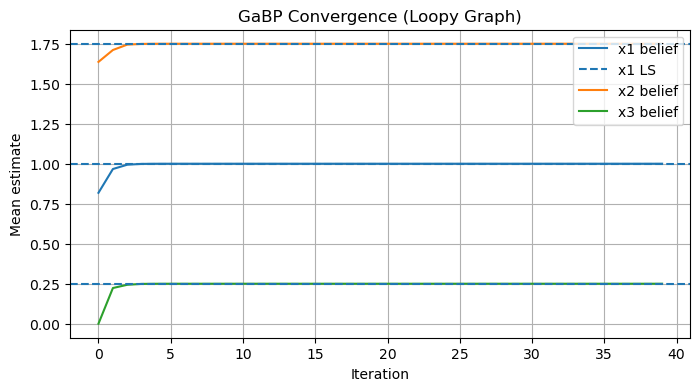

In [6]:
def plot_convergence(beliefs, x_ls, title):
    plt.figure(figsize=(8, 4))
    iters = beliefs.shape[0]
    for i in range(beliefs.shape[1]):
        plt.plot(range(iters), beliefs[:, i], label=f'x{i+1} belief')
        plt.axhline(x_ls[i], linestyle='--', label=f'x{i+1} LS' if i == 0 else None)
    plt.xlabel('Iteration')
    plt.ylabel('Mean estimate')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_convergence(beliefs_chain, x_chain_ls, 'GaBP Convergence (Chain Graph)')
plot_convergence(beliefs_loop, x_loop_ls, 'GaBP Convergence (Loopy Graph)')


## Visualizing Message Flows

We now visualize **factor → variable messages** for a chosen iteration.

- Variables $x_1, x_2, x_3$ are drawn as circles on the top row.
- Factors (unary and pairwise) are drawn as squares on the bottom row.
- Edges carry labels with the **mean** of the outgoing message from factor to variable.

If `ipywidgets` is available, a slider lets you step through iterations.


In [7]:
def extract_msg_means(msgs_iter, fg: GaussianFG):
    """Return a dict[(factor_key, i)] -> mean for factor->var at this iteration."""
    means = {}
    for key, (prec, info) in msgs_iter.items():
        fk, i = key  # factor key, variable index
        if prec > 0:
            mu = info / prec
        else:
            mu = 0.0
        means[(fk, i)] = mu
    return means

def plot_message_graph(msgs_iter, fg: GaussianFG, title=''):
    means = extract_msg_means(msgs_iter, fg)

    # Layout: variables on top (x-axis: 0,1,2), factors on bottom
    x_var = np.arange(fg.n_vars)
    y_var = np.ones(fg.n_vars) * 1.0
    # unary factors below each variable
    x_unary = x_var.copy()
    y_unary = np.zeros(fg.n_vars)
    # pairwise factors in-between
    pair_keys = fg.pair_edges
    x_pair = []
    y_pair = []
    for (i, j) in fg.pair_edges:
        x_pair.append(0.5 * (x_var[i] + x_var[j]))
        y_pair.append(-0.5)
    x_pair = np.array(x_pair)
    y_pair = np.array(y_pair)

    plt.figure(figsize=(8, 4))

    # Draw variable nodes
    plt.scatter(x_var, y_var, s=300, c='lightblue', edgecolors='k', zorder=3)
    for i in range(fg.n_vars):
        plt.text(x_var[i], y_var[i]+0.1, f'x{i+1}', ha='center', va='bottom')

    # Draw unary factor nodes
    plt.scatter(x_unary, y_unary, s=200, marker='s', c='lightgreen', edgecolors='k', zorder=3)
    for i in range(fg.n_vars):
        plt.text(x_unary[i], y_unary[i]-0.1, f'u{i+1}', ha='center', va='top')

    # Draw pairwise factor nodes
    for idx, (i, (a, b)) in enumerate(zip(range(len(fg.pair_edges)), fg.pair_edges)):
        plt.scatter(x_pair[idx], y_pair[idx], s=200, marker='s', c='orange', edgecolors='k', zorder=3)
        plt.text(x_pair[idx], y_pair[idx]-0.1, f'p{a+1}{b+1}', ha='center', va='top')

    # Draw edges + message labels
    # unary edges
    for i in range(fg.n_vars):
        fk = ('u', i)
        # line
        plt.plot([x_unary[i], x_var[i]], [y_unary[i], y_var[i]], 'k-', alpha=0.5)
        mu = means.get(((fk), i), 0.0)
        xm = 0.5*(x_unary[i] + x_var[i])
        ym = 0.5*(y_unary[i] + y_var[i])
        plt.text(xm, ym, f'{mu:.2f}', ha='center', va='center', fontsize=8, color='red')

    # pairwise edges
    for idx, (a, b) in enumerate(fg.pair_edges):
        fk = ('p', a, b)
        # edges to a
        plt.plot([x_pair[idx], x_var[a]], [y_pair[idx], y_var[a]], 'k-', alpha=0.5)
        mu_a = means.get(((fk), a), 0.0)
        xm_a = 0.5*(x_pair[idx] + x_var[a])
        ym_a = 0.5*(y_pair[idx] + y_var[a])
        plt.text(xm_a, ym_a, f'{mu_a:.2f}', ha='center', va='center', fontsize=8, color='purple')
        # edges to b
        plt.plot([x_pair[idx], x_var[b]], [y_pair[idx], y_var[b]], 'k-', alpha=0.5)
        mu_b = means.get(((fk), b), 0.0)
        xm_b = 0.5*(x_pair[idx] + x_var[b])
        ym_b = 0.5*(y_pair[idx] + y_var[b])
        plt.text(xm_b, ym_b, f'{mu_b:.2f}', ha='center', va='center', fontsize=8, color='purple')

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS:
    print('Interactive widgets are available. Use the slider to inspect message flows.')
else:
    print('ipywidgets not available; you can still call plot_message_graph(msgs_chain[k], fg_chain, ...) manually.')


Interactive widgets are available. Use the slider to inspect message flows.


In [ ]:
if HAS_WIDGETS:
    def explore_messages_chain(iteration=0):
        iteration = int(iteration)
        iteration = max(0, min(iteration, len(msgs_chain)-1))
        title = f'Chain graph, factor→variable messages at iteration {iteration}'
        plot_message_graph(msgs_chain[iteration], fg_chain, title)

    def explore_messages_loop(iteration=0):
        iteration = int(iteration)
        iteration = max(0, min(iteration, len(msgs_loop)-1))
        title = f'Loop graph, factor→variable messages at iteration {iteration}'
        plot_message_graph(msgs_loop[iteration], fg_loop, title)

    print('Use the sliders to visualize messages over iterations.')
    display(interact(explore_messages_chain, iteration=IntSlider(min=0, max=len(msgs_chain)-1, step=1, value=0)))
    display(interact(explore_messages_loop, iteration=IntSlider(min=0, max=len(msgs_loop)-1, step=1, value=0)))
else:
    # Example static plot if widgets are not available
    plot_message_graph(msgs_chain[-1], fg_chain, title='Chain graph (final iteration messages)')
    plot_message_graph(msgs_loop[-1], fg_loop, title='Loop graph (final iteration messages)')


Use the sliders to visualize messages over iterations.


interactive(children=(IntSlider(value=0, description='iteration', max=39), Output()), _dom_classes=('widget-in…

<function __main__.explore_messages_chain(iteration=0)>

interactive(children=(IntSlider(value=0, description='iteration', max=39), Output()), _dom_classes=('widget-in…

<function __main__.explore_messages_loop(iteration=0)>